In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\Sliit documents\Y2 Sem 1\AI\Dataset project\Final project dataset model trainning\pipline3.csv")

In [4]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (16964, 20)

First 5 rows:
    Unnamed: 0       age  hypertension  heart_disease       bmi  HbA1c_level  \
0        9065  1.000000             0              0  0.208314     0.090909   
1       22396  1.000000             1              0  0.381653     0.400000   
2       41915  0.712212             0              0  0.353862     0.454545   
3       30911  0.812312             1              0  0.233396     0.600000   
4       32402  0.000000             0              0  0.039802     0.272727   

   blood_glucose_level  diabetes  bmi_category  age_group  \
0             0.022727         0             3          4   
1             0.272727         1             4          4   
2             0.045455         0             4          3   
3             0.359091         1             4          3   
4             0.022727         0             1          1   

   htn_heart_interaction  gender_Female  gender_Male  gender_Other  \
0                      0              0      

In [5]:
df = df.dropna()

In [6]:
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [8]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
rf = RandomForestClassifier(random_state=42)

In [19]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print(" Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
 Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


In [13]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'entropy'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = best_rf.predict(X_test)

In [16]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      1673
           1       0.91      0.91      0.91      1720

    accuracy                           0.91      3393
   macro avg       0.91      0.91      0.91      3393
weighted avg       0.91      0.91      0.91      3393



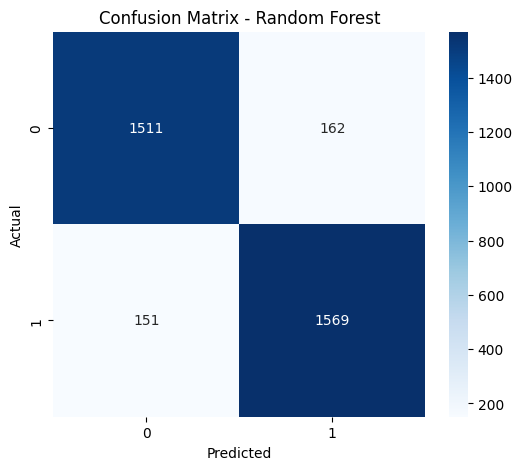

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

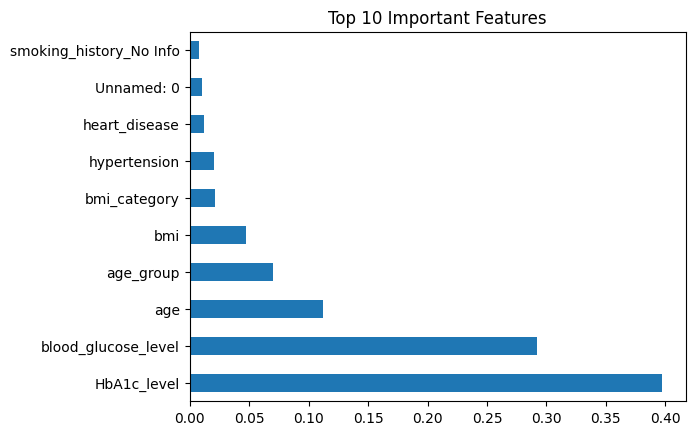

In [18]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', title="Top 10 Important Features")
plt.show()